# 05 — Stacked-Bar β Decomposition by PV-Tendency Term

For each lifecycle hour (dh = −13 … +12), project **individual** PV-tendency terms
onto the composite-mean orthogonal basis (built from dh−1) and extract the **β**
(intensification) coefficient.

The result is a stacked bar chart showing how each physical process contributes
to block intensification / de-intensification across the lifecycle.

**Data**: `composite_state.pkl` (pre-aggregated SUMS3D / VALID3D)  
**Smoothing**: 3° Gaussian  
**Basis**: always from dh−1 (predictive framing)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan

## 1  Configuration

In [2]:
PKL_PATH   = "/net/flood/data2/users/x_yan/tempest_extreme_4_basis/outputs_prp/composite_state.pkl"
STAGE      = "onset"
LEVEL      = 200           # "wavg" for mass-weighted vertical avg, or int hPa (e.g. 200, 250, 500)
SMOOTH_DEG = 3.0
GRID_SP    = 1.5           # grid spacing in degrees

_lvl_str = f"{LEVEL} hPa" if isinstance(LEVEL, int) else "wavg"
print(f"Stage: {STAGE}   Level: {_lvl_str}   Smoothing: {SMOOTH_DEG}°   Grid: {GRID_SP}°")

Stage: onset   Level: 200 hPa   Smoothing: 3.0°   Grid: 1.5°


## 2  Load composite_state.pkl & build composite means

In [3]:
with open(PKL_PATH, "rb") as f:
    _state = pickle.load(f)
_g = _state["globals"]

SUMS3D    = _g["SUMS3D"][STAGE]       # {dh: {field_3d: (nlev, ny, nx)}}
VALID3D   = _g["VALID3D"][STAGE]      # {dh: {field_3d: (nlev, ny, nx)}}
FILECOUNT = _g["FILECOUNT"][STAGE]    # {dh: int}
LEVELS    = _g["LEVELS"]             # (nlev,)
X_REL     = _g["X_REL"]             # (ny, nx)
Y_REL     = _g["Y_REL"]
H_SCALE   = _g["H_SCALE"]

DH_RANGE  = sorted(SUMS3D.keys())
x_rel = X_REL[0, :]
y_rel = Y_REL[:, 0]

# Level index (for single-level mode)
if isinstance(LEVEL, int):
    _lev_idx = int(np.argmin(np.abs(LEVELS - LEVEL)))
    print(f"Level index: {_lev_idx}  →  {LEVELS[_lev_idx]} hPa")

del _state  # free ~8 GB; SUMS3D/VALID3D are dict refs kept alive
print(f"dh range: {DH_RANGE[0]} … {DH_RANGE[-1]}  ({len(DH_RANGE)} steps)")
print(f"Fields per dh: {len(SUMS3D[DH_RANGE[0]])}   Levels: {LEVELS}")


def _composite_mean(dh, field_name):
    """Return the composite-mean 2-D field at the configured LEVEL."""
    key = field_name if field_name.endswith("_3d") else field_name + "_3d"
    s = SUMS3D[dh][key]            # (nlev, ny, nx)
    v = VALID3D[dh][key]           # (nlev, ny, nx)
    if isinstance(LEVEL, int):
        # Single isobaric level
        s2 = s[_lev_idx]
        v2 = v[_lev_idx]
        return np.where(v2 > 0, s2 / v2, np.nan)
    else:
        # Mass-weighted vertical average using exp(-z/H) weights
        # For the pkl, z_3d sums/valid give us mean z per level
        z_s = SUMS3D[dh]["z_3d"]
        z_v = VALID3D[dh]["z_3d"]
        z_mean = np.where(z_v > 0, z_s / z_v, np.nan)     # (nlev, ny, nx)
        f_mean = np.where(v > 0, s / v, np.nan)            # (nlev, ny, nx)
        w = np.exp(-z_mean / H_SCALE)
        valid = np.isfinite(f_mean)
        num = np.nansum(np.where(valid, f_mean * w, 0.0), axis=0)
        den = np.nansum(np.where(valid, w,           0.0), axis=0)
        return np.where(den > 0, num / den, np.nan)

# Sanity check
_test = _composite_mean(0, "pv_anom")
print(f"pv_anom at dh=0: shape={_test.shape}, range=[{np.nanmin(_test):.3e}, {np.nanmax(_test):.3e}]")

Level index: 7  →  200 hPa
dh range: -13 … 12  (26 steps)
Fields per dh: 82   Levels: [1000  850  700  500  400  300  250  200  100]
pv_anom at dh=0: shape=(29, 49), range=[-1.949e-06, 9.666e-07]


## 3  Define individual RHS terms

In [4]:
# Term name → callable(dh) → 2-D composite-mean field
TERMS = {
    r"$\mathrm{d}q/\mathrm{d}t$":   lambda dh: _composite_mean(dh, "pv_anom_dt") + _composite_mean(dh, "pv_bar_dt"),
    r"$-\bar{u}\,q'_x$":             lambda dh: -_composite_mean(dh, "u_bar_pv_anom_dx"),
    r"$-v'\,\bar{q}_y$":             lambda dh: -_composite_mean(dh, "v_anom_pv_bar_dy"),
    r"$-\omega'\,\bar{q}_p$":        lambda dh: -_composite_mean(dh, "w_anom_pv_bar_dp"),
    r"$-\omega'\,q'_p$":             lambda dh: -_composite_mean(dh, "w_anom_pv_anom_dp"),
    r"$Q$":                           lambda dh: _composite_mean(dh, "Q"),
    r"Div. eddy":                     lambda dh: -(_composite_mean(dh, "u_div_pv_anom_dx")
                                                    + _composite_mean(dh, "v_div_pv_anom_dy")),
    r"Rot. eddy":                     lambda dh: -(_composite_mean(dh, "u_rot_pv_anom_dx")
                                                    + _composite_mean(dh, "v_rot_pv_anom_dy")),
}
TERM_NAMES = list(TERMS.keys())
print("Terms:", TERM_NAMES)

Terms: ['$\\mathrm{d}q/\\mathrm{d}t$', "$-\\bar{u}\\,q'_x$", "$-v'\\,\\bar{q}_y$", "$-\\omega'\\,\\bar{q}_p$", "$-\\omega'\\,q'_p$", '$Q$', 'Div. eddy', 'Rot. eddy']


## 4  Lifecycle loop — project every term onto composite basis (dh−1)

In [5]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# Storage: term_name → list of β values (one per dh)
beta_lifecycle = {name: [] for name in TERM_NAMES}
n_events_arr = []

for dh in DH_RANGE:
    n_events_arr.append(FILECOUNT[dh])

    # --- Composite-mean basis from dh-1 ---
    dh_basis = max(dh - 1, DH_RANGE[0])
    pv_anom_mean = _composite_mean(dh_basis, "pv_anom")
    pv_dx_mean   = _composite_mean(dh_basis, "pv_anom_dx")
    pv_dy_mean   = _composite_mean(dh_basis, "pv_anom_dy")

    basis = compute_orthogonal_basis(
        pv_anom_mean, pv_dx_mean, pv_dy_mean,
        x_rel, y_rel,
        mask_negative=True,
        apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
    )

    # --- Project composite-mean of each term ---
    for name, func in TERMS.items():
        fld_mean = func(dh)
        fld_s = smooth(fld_mean)
        p = project_field(fld_s, basis)
        beta_lifecycle[name].append(p["beta"])

    sign = "+" if dh >= 0 else ""
    print(f"dh={sign}{dh:>3d}  N={FILECOUNT[dh]:4d}  "
          f"β(dq/dt)={beta_lifecycle[TERM_NAMES[0]][-1]:.3e}")

# Convert to arrays
dh_arr = np.array(DH_RANGE)
n_events_arr = np.array(n_events_arr)
for name in TERM_NAMES:
    beta_lifecycle[name] = np.array(beta_lifecycle[name])

print(f"\nDone.  dh range: {dh_arr[0]} … {dh_arr[-1]}   LEVEL={LEVEL}")

dh=-13  N=1909  β(dq/dt)=4.981e-06
dh=-12  N=1909  β(dq/dt)=4.774e-06
dh=-11  N=1909  β(dq/dt)=4.599e-06
dh=-10  N=1909  β(dq/dt)=4.544e-06
dh= -9  N=1909  β(dq/dt)=4.166e-06
dh= -8  N=1909  β(dq/dt)=3.920e-06
dh= -7  N=1909  β(dq/dt)=4.002e-06
dh= -6  N=1909  β(dq/dt)=3.966e-06
dh= -5  N=1909  β(dq/dt)=3.738e-06
dh= -4  N=1909  β(dq/dt)=3.564e-06
dh= -3  N=1909  β(dq/dt)=3.244e-06
dh= -2  N=1909  β(dq/dt)=3.147e-06
dh= -1  N=1909  β(dq/dt)=3.322e-06
dh=+  0  N=1910  β(dq/dt)=3.089e-06
dh=+  1  N=1910  β(dq/dt)=2.661e-06
dh=+  2  N=1910  β(dq/dt)=2.589e-06
dh=+  3  N=1910  β(dq/dt)=2.655e-06
dh=+  4  N=1910  β(dq/dt)=2.553e-06
dh=+  5  N=1910  β(dq/dt)=2.429e-06
dh=+  6  N=1910  β(dq/dt)=2.378e-06
dh=+  7  N=1910  β(dq/dt)=2.202e-06
dh=+  8  N=1910  β(dq/dt)=1.955e-06
dh=+  9  N=1910  β(dq/dt)=1.550e-06
dh=+ 10  N=1910  β(dq/dt)=1.150e-06
dh=+ 11  N=1910  β(dq/dt)=1.095e-06
dh=+ 12  N=1910  β(dq/dt)=9.120e-07

Done.  dh range: -13 … 12   LEVEL=200


## 5  Stacked bar chart — β contributions

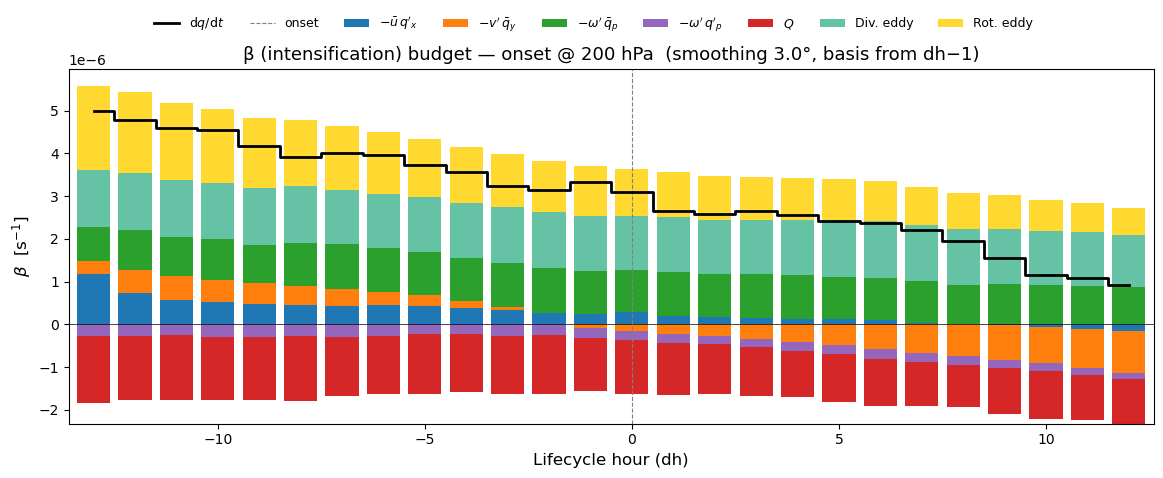

In [6]:
# Colors sampled from matplotlib qualitative colormaps (colorblind-safe)
# https://matplotlib.org/stable/users/explain/colors/colormaps.html
_tab10 = plt.cm.tab10      # 10-class qualitative (perceptually distinct)
_set2  = plt.cm.Set2        # 8-class qualitative  (ColorBrewer, softer)

TERM_COLORS = {
    TERM_NAMES[0]: "black",            # dq/dt  (step line overlay)
    TERM_NAMES[1]: _tab10(0),          # -ū q'_x   (tab10 blue)
    TERM_NAMES[2]: _tab10(1),          # -v' q̄_y   (tab10 orange)
    TERM_NAMES[3]: _tab10(2),          # -ω' q̄_p   (tab10 green)
    TERM_NAMES[4]: _tab10(4),          # -ω' q'_p  (tab10 purple)
    TERM_NAMES[5]: _tab10(3),          # Q          (tab10 red)
    TERM_NAMES[6]: _set2(0),           # Div. eddy  (Set2 teal)
    TERM_NAMES[7]: _set2(5),           # Rot. eddy  (Set2 gold)
}

# Separate RHS terms from the total tendency
rhs_names = TERM_NAMES[1:]   # everything except dq/dt
_lvl_str = f"{LEVEL} hPa" if isinstance(LEVEL, int) else "wavg"

fig, ax = plt.subplots(figsize=(14, 5))
bar_width = 0.8

# Build positive and negative stacks separately
pos_bottom = np.zeros(len(dh_arr))
neg_bottom = np.zeros(len(dh_arr))

for name in rhs_names:
    vals = beta_lifecycle[name]
    pos_vals = np.where(vals > 0, vals, 0)
    neg_vals = np.where(vals < 0, vals, 0)

    ax.bar(dh_arr, pos_vals, bottom=pos_bottom, width=bar_width,
           color=TERM_COLORS[name], edgecolor="none", label=name)
    ax.bar(dh_arr, neg_vals, bottom=neg_bottom, width=bar_width,
           color=TERM_COLORS[name], edgecolor="none")

    pos_bottom += pos_vals
    neg_bottom += neg_vals

# Overlay dq/dt as a black step line
ax.step(dh_arr, beta_lifecycle[TERM_NAMES[0]], where="mid",
        color="black", lw=2, label=TERM_NAMES[0], zorder=5)

ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="grey", lw=0.8, ls="--", label="onset")
ax.set_xlabel("Lifecycle hour (dh)", fontsize=12)
ax.set_ylabel(r"$\beta$  [s$^{-1}$]", fontsize=12)
ax.set_title(f"β (intensification) budget — {STAGE} @ {_lvl_str}  "
             f"(smoothing {SMOOTH_DEG}°, basis from dh−1)", fontsize=13)

# Legend outside the axes, centered below the title like a subtitle
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, 0.95), ncol=len(labels),
           fontsize=9, frameon=False)

ax.set_xlim(dh_arr[0] - 0.6, dh_arr[-1] + 0.6)
fig.subplots_adjust(top=0.82)
plt.show()

## Summary

- **`LEVEL`** controls vertical selection: `"wavg"` for mass-weighted column average (exp(−z/H) weights), or an integer (e.g. `200`, `500`) for a single isobaric level in hPa.
- **Data source**: `composite_state.pkl` — pre-aggregated SUMS3D / VALID3D composites (no per-event NPZ I/O).
- **Stacked bars** show the contribution of each PV-tendency term to the **β (intensification)** coefficient across the blocking lifecycle.
- Positive bars above zero indicate processes that intensify the block (deepen the negative PV anomaly).
- The black step line shows the **total dq/dt** tendency; the stacked RHS terms should approximately reproduce it.
- **Basis**: composite-mean from dh−1 (predictive framing) with Gaussian smoothing.